# Best Reduced-Channel Benchmark

This notebook fixes the strongest reduced-channel configuration from `benchmarks_improvements.ipynb` and reruns it with focused diagnostics.

Chosen reduced-channel configuration:

- model: `EEGNet`
- evaluation: pooled cross-subject split
- channels: `sensorimotor_17`
- band-pass: `8 to 30 Hz`
- crop window: `0.5 to 2.5 s`
- sampling rate: `160 Hz`

The notebook keeps the same inline plotting style as the all-channel version, but highlights the selected motor-area channels.


In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import EEGNet
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
RUNS = [4, 8, 12]
RESAMPLE_SFREQ = 160.0
FILTER_BAND = (8.0, 30.0)
EPOCH_WINDOW = (0.0, 4.0)
CROP_WINDOW = (0.5, 2.5)
TEST_SIZE = 0.2
VAL_SIZE = 0.2
MAX_SUBJECTS = None
BATCH_SIZE = 64
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
REDUCED_CHANNELS = [
    "FC5",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "FC6",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CPz",
    "CP4",
]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int] = RUNS) -> mne.io.BaseRaw:
    paths = local_run_paths(subject, runs)
    if not all(path.exists() for path in paths):
        missing = [path.name for path in paths if not path.exists()]
        raise FileNotFoundError(
            f"Missing EDF files for subject {subject:03d}: {missing}"
        )

    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    raw.filter(
        *FILTER_BAND, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )
    return raw


def epoch_subject(raw: mne.io.BaseRaw) -> tuple[np.ndarray, np.ndarray, Epochs]:
    events, event_map = mne.events_from_annotations(raw, verbose="ERROR")
    epochs = Epochs(
        raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*CROP_WINDOW)

    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])

    X = epochs.get_data(copy=False).astype(np.float32)
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)
    return X, y, epochs


def select_reduced_channels(
    X: np.ndarray, ch_names: list[str], chs_info: list[dict], wanted: list[str]
):
    name_to_idx = {name: idx for idx, name in enumerate(ch_names)}
    picks = [name_to_idx[ch] for ch in wanted if ch in name_to_idx]
    X = X[:, picks, :]
    names = [ch_names[idx] for idx in picks]
    info = [deepcopy(chs_info[idx]) for idx in picks]
    return X, names, info, picks


def build_dataset(subjects=None) -> dict:
    if subjects is None:
        subjects = infer_available_subjects()
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]

    X_parts = []
    y_parts = []
    groups = []
    full_channel_names = None
    full_chs_info = None
    reduced_channel_names = None
    reduced_chs_info = None
    reduced_picks = None
    example_epochs = None
    kept_subjects = []

    for subject in subjects:
        raw = load_subject_raw(subject)
        X, y, epochs = epoch_subject(raw)
        if full_channel_names is None:
            full_channel_names = epochs.ch_names
            full_chs_info = deepcopy(epochs.info["chs"])
            example_epochs = epochs.copy()
            _, reduced_channel_names, reduced_chs_info, reduced_picks = (
                select_reduced_channels(
                    X,
                    full_channel_names,
                    full_chs_info,
                    REDUCED_CHANNELS,
                )
            )
        elif epochs.ch_names != full_channel_names:
            raise RuntimeError(f"Channel mismatch for subject {subject:03d}")

        X = X[:, reduced_picks, :]
        mean = X.mean(axis=2, keepdims=True)
        std = X.std(axis=2, keepdims=True) + 1e-6
        X = (X - mean) / std

        X_parts.append(X)
        y_parts.append(y)
        groups.append(np.full(len(y), subject))
        kept_subjects.append(subject)

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "subjects": kept_subjects,
        "channel_names": reduced_channel_names,
        "chs_info": reduced_chs_info,
        "sfreq": RESAMPLE_SFREQ,
        "example_epochs": example_epochs,
        "reduced_picks": reduced_picks,
        "full_channel_names": full_channel_names,
    }


def make_group_split(groups: np.ndarray, seed: int = SEED) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed + 1)
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), groups=groups[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


set_seed()
dataset = build_dataset()
split = make_group_split(dataset["groups"])

dataset_summary = pd.DataFrame(
    {
        "metric": [
            "subjects_used",
            "epochs_total",
            "left_trials",
            "right_trials",
            "channels_used",
            "sampling_rate_hz",
            "samples_per_epoch",
            "crop_window_s",
            "filter_band_hz",
        ],
        "value": [
            len(dataset["subjects"]),
            len(dataset["y"]),
            int((dataset["y"] == 0).sum()),
            int((dataset["y"] == 1).sum()),
            len(dataset["channel_names"]),
            dataset["sfreq"],
            dataset["X"].shape[-1],
            str(CROP_WINDOW),
            str(FILTER_BAND),
        ],
    }
)
display(dataset_summary)
print("Reduced channels:", ", ".join(dataset["channel_names"]))


,metric,value
0,subjects_used,109
1,epochs_total,4898
2,left_trials,2470
3,right_trials,2428
4,channels_used,17
5,sampling_rate_hz,160.0
6,samples_per_epoch,320
7,crop_window_s,"(0.5, 2.5)"
8,filter_band_hz,"(8.0, 30.0)"


Reduced channels: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, CP3, CPz, CP4


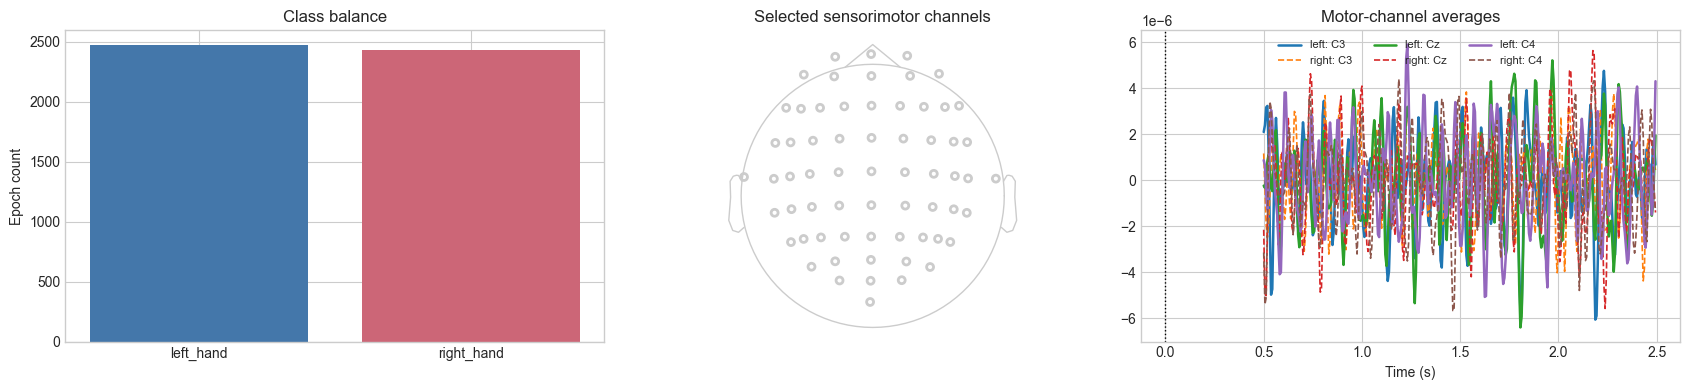

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

class_counts = (
    pd.Series(dataset["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
axes[0].bar(class_counts.index, class_counts.values, color=["#4477AA", "#CC6677"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Epoch count")

mne.viz.plot_sensors(
    dataset["example_epochs"].info,
    axes=axes[1],
    show=False,
    kind="topomap",
    ch_groups=[dataset["reduced_picks"]],
)
axes[1].set_title("Selected sensorimotor channels")

motor_channels = [
    ch for ch in ["C3", "Cz", "C4"] if ch in dataset["example_epochs"].ch_names
]
left_evoked = dataset["example_epochs"]["left_hand"].average().pick(motor_channels)
right_evoked = dataset["example_epochs"]["right_hand"].average().pick(motor_channels)
for ch_name in motor_channels:
    idx = left_evoked.ch_names.index(ch_name)
    axes[2].plot(
        left_evoked.times,
        left_evoked.data[idx],
        label=f"left: {ch_name}",
        linewidth=1.8,
    )
    axes[2].plot(
        right_evoked.times,
        right_evoked.data[idx],
        label=f"right: {ch_name}",
        linestyle="--",
        linewidth=1.2,
    )
axes[2].axvline(0.0, color="black", linestyle=":", linewidth=1)
axes[2].set_title("Motor-channel averages")
axes[2].set_xlabel("Time (s)")
axes[2].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()


In [4]:
def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
    )


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def collect_predictions(
    model: nn.Module, loader: DataLoader
) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    pred_labels = []
    pred_probs = []
    for batch_X, _ in loader:
        batch_X = batch_X.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        probs = torch.softmax(logits, dim=1)[:, 1]
        pred_probs.append(probs.cpu().numpy())
        pred_labels.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(pred_labels), np.concatenate(pred_probs)


def evaluate_loss_accuracy(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        loss = criterion(logits, batch_y)
        total_loss += loss.item() * len(batch_y)
        total_correct += (logits.argmax(dim=1) == batch_y).sum().item()
        total_count += len(batch_y)
    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


X_train, y_train = dataset["X"][split["train"]], dataset["y"][split["train"]]
X_val, y_val = dataset["X"][split["val"]], dataset["y"][split["val"]]
X_test, y_test = dataset["X"][split["test"]], dataset["y"][split["test"]]

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val, shuffle=False)
test_loader = make_loader(X_test, y_test, shuffle=False)

model = EEGNet(
    n_chans=X_train.shape[1],
    n_times=X_train.shape[2],
    n_outputs=2,
    sfreq=dataset["sfreq"],
    chs_info=dataset["chs_info"],
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
history = []
best_state = None
best_val_balanced_accuracy = -np.inf
best_epoch = 0
patience_counter = 0
start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = unpack_logits(model(batch_X))
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

    train_loss, train_accuracy = evaluate_loss_accuracy(model, train_loader, criterion)
    val_loss, val_accuracy = evaluate_loss_accuracy(model, val_loader, criterion)
    val_pred, _ = collect_predictions(model, val_loader)
    val_balanced_accuracy = balanced_accuracy_score(y_val, val_pred)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "val_balanced_accuracy": val_balanced_accuracy,
        }
    )

    if val_balanced_accuracy > best_val_balanced_accuracy + 1e-4:
        best_val_balanced_accuracy = val_balanced_accuracy
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            break

training_time_s = time.perf_counter() - start
if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df)


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_balanced_accuracy
0,1,0.692949,0.692994,0.518865,0.496287,0.492794
1,2,0.692283,0.692907,0.546598,0.502475,0.500898
2,3,0.691210,0.693070,0.508546,0.507426,0.513264
3,4,0.685110,0.688114,0.600774,0.564356,0.566128
4,5,0.662054,0.665782,0.618510,0.589109,0.590639
5,6,0.636791,0.643605,0.648178,0.618812,0.615996
6,7,0.612363,0.627372,0.650113,0.637376,0.635712
7,8,0.609066,0.625946,0.649790,0.647277,0.644542
8,9,0.595982,0.616091,0.670106,0.654703,0.653838
9,10,0.588038,0.613671,0.670751,0.660891,0.659277


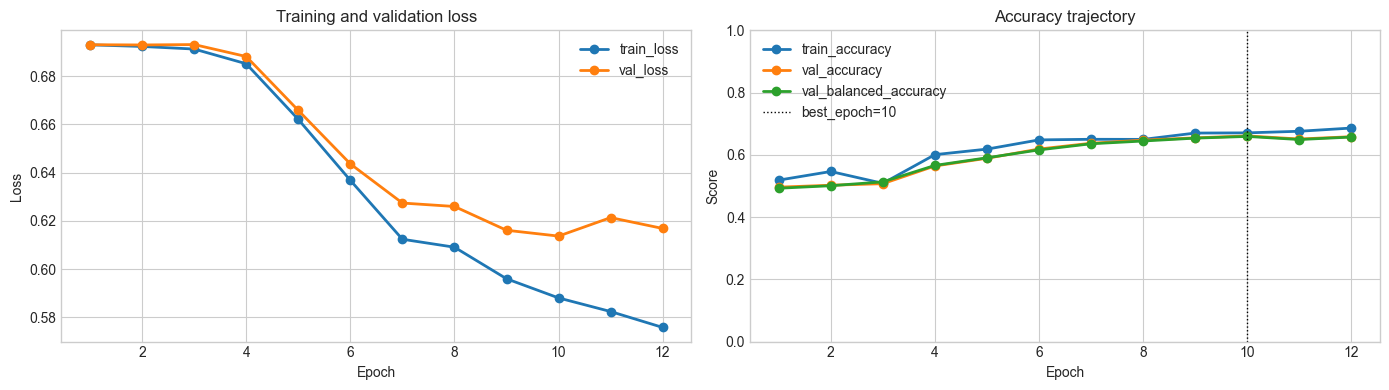

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="train_loss",
)
axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    linewidth=2,
    label="val_loss",
)
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    linewidth=2,
    label="train_accuracy",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    linewidth=2,
    label="val_accuracy",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    marker="o",
    linewidth=2,
    label="val_balanced_accuracy",
)
axes[1].axvline(
    best_epoch,
    color="black",
    linestyle=":",
    linewidth=1,
    label=f"best_epoch={best_epoch}",
)
axes[1].set_title("Accuracy trajectory")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
test_pred, test_prob = collect_predictions(model, test_loader)
test_accuracy = (test_pred == y_test).mean()
test_balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

summary = pd.DataFrame(
    {
        "metric": [
            "test_accuracy",
            "test_balanced_accuracy",
            "test_auc",
            "best_epoch",
            "training_time_s",
        ],
        "value": [
            test_accuracy,
            test_balanced_accuracy,
            test_auc,
            best_epoch,
            training_time_s,
        ],
    }
)
display(summary)
print(
    classification_report(y_test, test_pred, target_names=["left_hand", "right_hand"])
)


,metric,value
0,test_accuracy,0.586451
1,test_balanced_accuracy,0.585489
2,test_auc,0.629918
3,best_epoch,10.000000
4,training_time_s,7.831159


              precision    recall  f1-score   support

   left_hand       0.58      0.67      0.62       500
  right_hand       0.60      0.50      0.54       489

    accuracy                           0.59       989
   macro avg       0.59      0.59      0.58       989
weighted avg       0.59      0.59      0.58       989



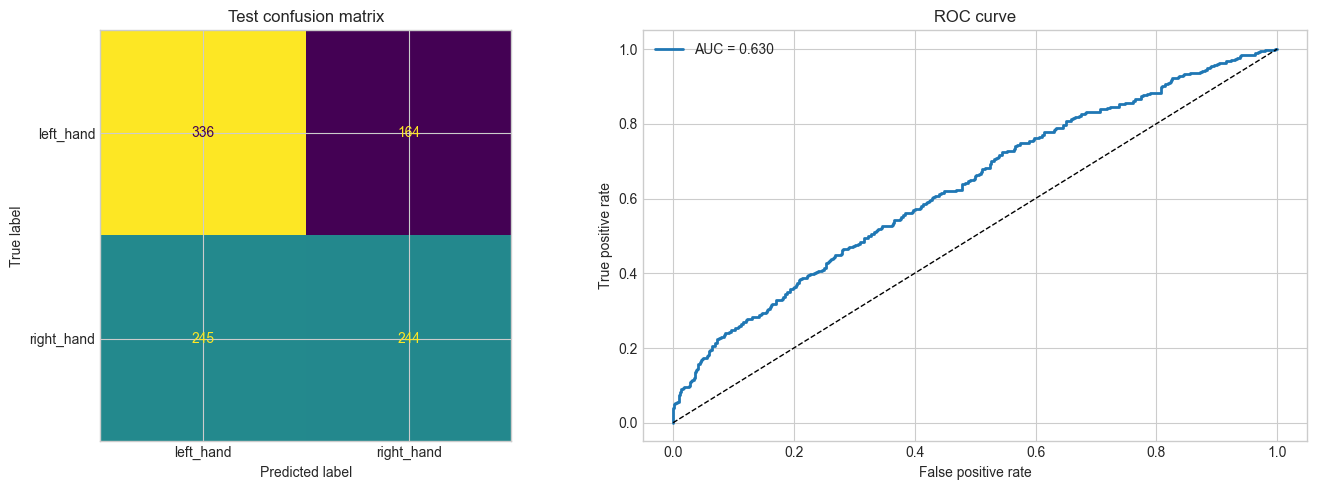

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["left_hand", "right_hand"]).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title("Test confusion matrix")

fpr, tpr, _ = roc_curve(y_test, test_prob)
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {test_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
axes[1].set_title("ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()

plt.tight_layout()
plt.show()


,subject,n_trials,accuracy,balanced_accuracy,mean_pred_prob_right
16,94,45,0.822222,0.819170,0.555288
6,38,45,0.688889,0.686759,0.447369
2,14,45,0.666667,0.666008,0.509382
9,50,45,0.666667,0.662055,0.447353
3,21,45,0.622222,0.645833,0.630753
15,86,45,0.644444,0.645257,0.480757
4,23,45,0.644444,0.643281,0.496698
8,47,45,0.644444,0.642857,0.488086
10,51,45,0.644444,0.633929,0.461218
20,107,45,0.622222,0.627976,0.493748


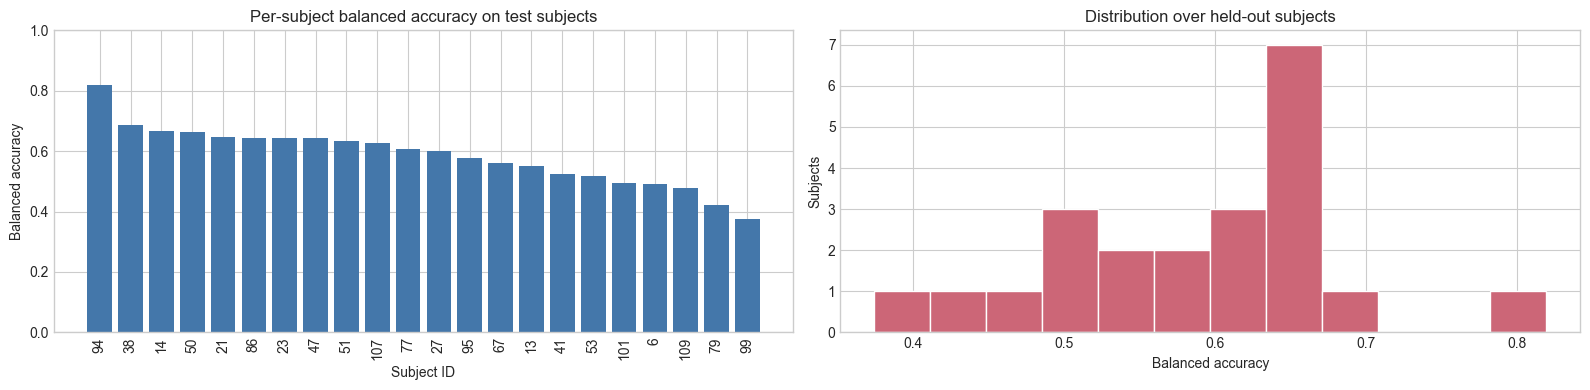

In [8]:
test_subjects = dataset["groups"][split["test"]]
per_subject_rows = []
for subject in np.unique(test_subjects):
    mask = test_subjects == subject
    y_subject = y_test[mask]
    pred_subject = test_pred[mask]
    prob_subject = test_prob[mask]
    per_subject_rows.append(
        {
            "subject": int(subject),
            "n_trials": int(mask.sum()),
            "accuracy": float((pred_subject == y_subject).mean()),
            "balanced_accuracy": float(
                balanced_accuracy_score(y_subject, pred_subject)
            ),
            "mean_pred_prob_right": float(prob_subject.mean()),
        }
    )

per_subject_df = pd.DataFrame(per_subject_rows).sort_values(
    "balanced_accuracy", ascending=False
)
display(per_subject_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(
    per_subject_df["subject"].astype(str),
    per_subject_df["balanced_accuracy"],
    color="#4477AA",
)
axes[0].set_title("Per-subject balanced accuracy on test subjects")
axes[0].set_xlabel("Subject ID")
axes[0].set_ylabel("Balanced accuracy")
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis="x", rotation=90)

axes[1].hist(
    per_subject_df["balanced_accuracy"], bins=12, color="#CC6677", edgecolor="white"
)
axes[1].set_title("Distribution over held-out subjects")
axes[1].set_xlabel("Balanced accuracy")
axes[1].set_ylabel("Subjects")

plt.tight_layout()
plt.show()
